In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [ ]:
df = pd.read_parquet("../DATA/dataset/train_stage2")

In [5]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

### MCC + 

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def build_mcc_dummies(df, mcc_col="mcc", drop_first=True):
    X = pd.get_dummies(df[mcc_col].astype("int32"), prefix="mcc", drop_first=drop_first)
    return X

def drop_constant_cols(X: pd.DataFrame) -> pd.DataFrame:
    nun = X.nunique(dropna=False)
    return X.drop(columns=nun[nun <= 1].index, errors="ignore")

def drop_rare_cols(X: pd.DataFrame, min_pos=50) -> pd.DataFrame:

    pos = X.sum(axis=0)
    return X.drop(columns=pos[pos < min_pos].index, errors="ignore")

def drop_perfect_separation_cols(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:

    yv = y.values
    drop_cols = []
    for c in X.columns:
        m = X[c].values.astype(bool)
        if m.sum() == 0:
            drop_cols.append(c); continue
        y_sub = yv[m]
     
        if y_sub.min() == y_sub.max():
            drop_cols.append(c)
    return X.drop(columns=drop_cols, errors="ignore")

def compute_vif_df(X: pd.DataFrame) -> pd.DataFrame:
    # VIF 계산(상수 제외)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_ = X.copy()
    if "const" in X_.columns:
        X_ = X_.drop(columns=["const"])
    arr = X_.astype(float).values
    vifs = []
    for i, col in enumerate(X_.columns):
        vifs.append((col, variance_inflation_factor(arr, i)))
    return pd.DataFrame(vifs, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)

def fit_logit_drop_until_ok(df, y_col="fraud", mcc_col="mcc",
                           min_pos=50, max_drop_steps=500):
    y = df[y_col].astype("int8")

    # 1) 더미 생성 + 기본 정리
    X = build_mcc_dummies(df, mcc_col=mcc_col, drop_first=True)
    X = drop_constant_cols(X)
    X = drop_rare_cols(X, min_pos=min_pos)
    X = drop_perfect_separation_cols(X, y)

    # 상수 추가
    X = sm.add_constant(X, has_constant="add").astype("float64")

    dropped = []
    last_err = None

    for step in range(max_drop_steps + 1):
        try:
            model = sm.Logit(y, X).fit(disp=0, maxiter=200)
            return model, X, dropped
        except np.linalg.LinAlgError as e:
            # Singular matrix
            last_err = e

            # 2) VIF로 드랍
            vif_df = compute_vif_df(X)
            if vif_df.empty:
                raise

            worst = vif_df.iloc[0]["feature"]
            X = X.drop(columns=[worst], errors="ignore")
            dropped.append(worst)

        except Exception as e:
            # Perfect separation / convergence 등도 같이 처리
            last_err = e

            # 너무 희소한 컬럼 
            if "const" in X.columns:
                X_no_const = X.drop(columns=["const"])
            else:
                X_no_const = X

            pos = X_no_const.sum(axis=0)
            rare = pos[pos < min_pos].index.tolist()

            if rare:
                X = X.drop(columns=rare, errors="ignore")
                dropped.extend(rare)
                continue

            raise

    raise RuntimeError(f"Failed to fit after dropping {len(dropped)} cols. Last error: {last_err}")

# ---- 실행 ----
model, X_used, dropped_cols = fit_logit_drop_until_ok(
    df,
    y_col="fraud",
    mcc_col="mcc",
    min_pos=100,          
    max_drop_steps=1000
)

print("FIT OK. used cols:", X_used.shape[1], "dropped:", len(dropped_cols))
print("top dropped (first 20):", dropped_cols[:20])
print(model.summary())

FIT OK. used cols: 20 dropped: 0
top dropped (first 20): []
                           Logit Regression Results                           
Dep. Variable:                  fraud   No. Observations:               608430
Model:                          Logit   Df Residuals:                   608410
Method:                           MLE   Df Model:                           19
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                 0.09449
Time:                        08:25:35   Log-Likelihood:                -32849.
converged:                       True   LL-Null:                       -36277.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4164      0.017   -266.348      0.000      -4.449      -4.384
mcc_4121      -2.6154      0.101    -25.916      0.000      -2.813     

In [71]:
high = ["5732", "5712", "5045", "5816", "5651", "4411"]
mid  = ["5193", "5311", "7996"]

df["mcc_risk_level"] = 0
df.loc[df["mcc"].isin(mid), "mcc_risk_level"] = 1
df.loc[df["mcc"].isin(high), "mcc_risk_level"] = 2

In [72]:
df["mcc_risk_level"].value_counts()

mcc_risk_level
0    549993
1     52002
2      6435
Name: count, dtype: int64

### Fraud History

In [4]:
df["client_fraud_last1"] = (
    df.groupby("client_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
df["card_fraud_last1"] = (
    df.groupby("card_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
f1 = df.groupby("client_id")["fraud"].shift(1)
f2 = df.groupby("client_id")["fraud"].shift(2)
f3 = df.groupby("client_id")["fraud"].shift(3)

df["client_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)
f1 = df.groupby("card_id")["fraud"].shift(1)
f2 = df.groupby("card_id")["fraud"].shift(2)
f3 = df.groupby("card_id")["fraud"].shift(3)

df["card_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)

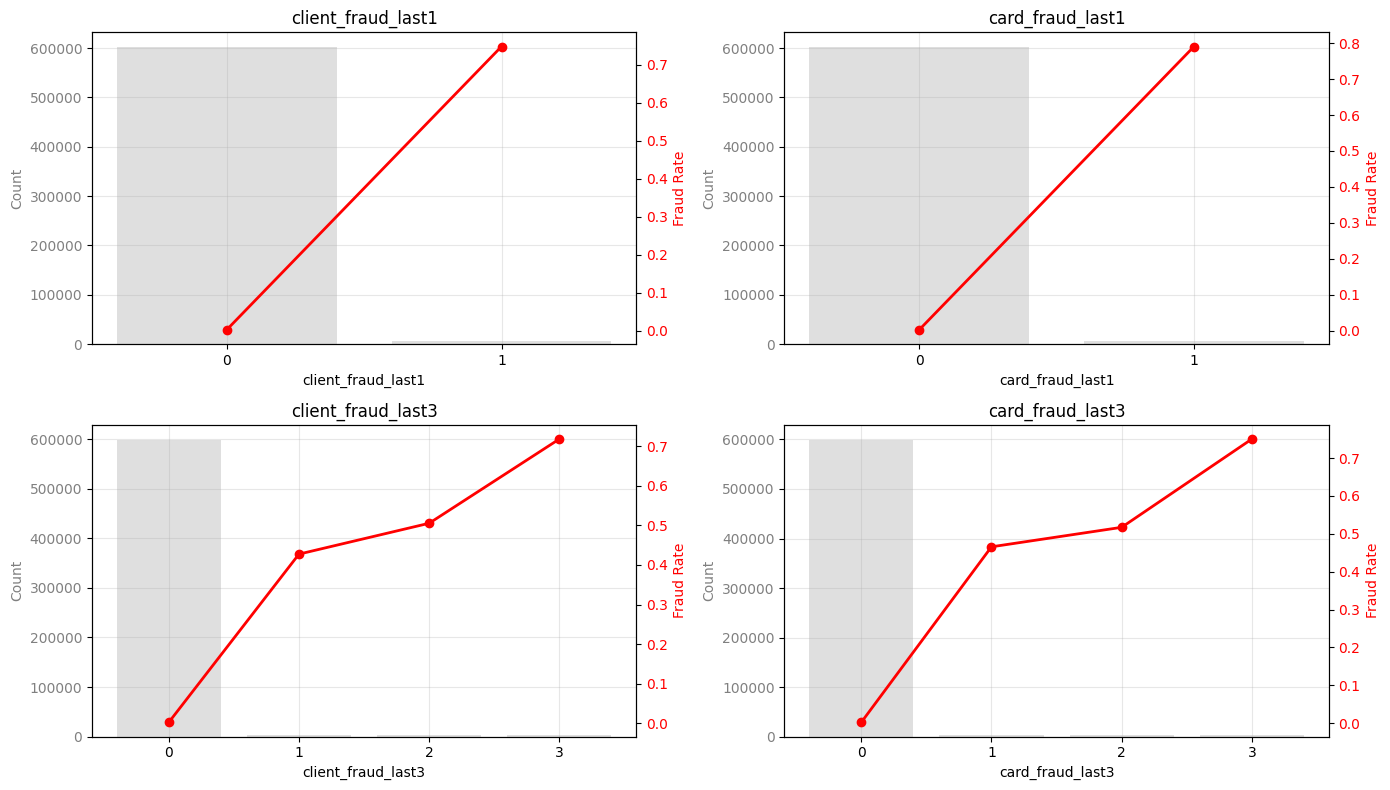

In [6]:
cols = ["client_fraud_last1", "card_fraud_last1", "client_fraud_last3", "card_fraud_last3"]

fig, axes = plt.subplots(2, 2, figsize=(14,8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    tmp = (
        df.groupby(col)["fraud"]
          .agg(rate="mean", cnt="size")
          .reset_index()
          .sort_values(col)
    )

    # count bars
    ax.bar(tmp[col].astype(str), tmp["cnt"], color="gray", alpha=0.25)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count", color="gray")
    ax.tick_params(axis="y", labelcolor="gray")
    ax.grid(True, alpha=0.3)

    # rate line on twin axis
    ax2 = ax.twinx()
    ax2.plot(tmp[col].astype(str), tmp["rate"], marker="o", linewidth=2, color="red")
    ax2.set_ylabel("Fraud Rate", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

In [9]:
cols = [    "client_fraud_last1",
            "client_fraud_last3",
            "card_fraud_last1",
            "card_fraud_last3"]
rows_uni = []
LABEL = "fraud"
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_fraud_last1,6.968571,1062.703070,0.0,0.010795,1.0,608430
1,client_fraud_last3,2.573415,13.110515,0.0,0.010795,1.0,608430
2,card_fraud_last1,7.350753,1557.369189,0.0,0.010795,1.0,608430
3,card_fraud_last3,2.613644,13.648703,0.0,0.010795,1.0,608430


In [10]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
   
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663464, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_fraud_last3,OK,2.564471,12.993789,0.0,0.010795,0.094374,8.742387,0.052151,4.830999,60843
1,client_fraud_last3,OK,2.519370,12.420767,0.0,0.010795,0.093848,8.693666,0.051625,4.782278,60843
2,card_fraud_last1,OK,7.242390,1397.429466,0.0,0.010795,0.092188,8.539890,0.049965,4.628502,60843
3,client_fraud_last1,OK,6.866129,959.227887,0.0,0.010795,0.090101,8.346529,0.047877,4.435140,60843


### Amount

In [11]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)
AMT = "log_abs_amount"

df["amt_shift"] = df.groupby("client_id")[AMT].shift(1)

df["amt_cumsum"] = (
    df["amt_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

df["amt_cnt_past"] = df.groupby("client_id").cumcount()

df["client_avg_amt_prev"] = np.where(
    df["amt_cnt_past"] > 0,
    df["amt_cumsum"] / df["amt_cnt_past"],
    df[AMT]  # 첫 거래는 중립 처리
).astype("float32")


In [ ]:
eps = 1e-6

df["amount_vs_client_avg_ratio"] = (
    df[AMT] / (df["client_avg_amt_prev"] + eps)
).astype("float32")

df["amount_vs_client_avg_diff"] = (
    df[AMT] - df["client_avg_amt_prev"]
).astype("float32")

df["log_amount_vs_client_avg_ratio"] = np.log1p(df["amount_vs_client_avg_ratio"]).astype("float32")


In [13]:
K = 10  # 최근 10건 기준 
df["client_recent_avg_amt"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(K, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
).astype("float32")

# 첫 거래는 NaN → 중립 처리
df["client_recent_avg_amt"] = df["client_recent_avg_amt"].fillna(df["client_avg_amt_prev"]).astype("float32")

df["amount_vs_recent_window_avg"] = (
    df[AMT] / (df["client_recent_avg_amt"] + eps)
).astype("float32")

df["log_amount_vs_recent_window_avg"] = np.log1p(df["amount_vs_recent_window_avg"]).astype("float32")


In [14]:
KQ = 50 
# 이 고객이 평소에 얼마나 큰 금액까지 써봤는가?

df["client_q95_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)   # 최소 10건 이상일 때만 의미
      .quantile(0.95)
      .reset_index(level=0, drop=True)
).astype("float32")

df["client_q99_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)
      .quantile(0.99)
      .reset_index(level=0, drop=True)
).astype("float32")

# NaN(거래 부족)일 때는 avg 기반으로 대체 (중립)
df["client_q95_prev"] = df["client_q95_prev"].fillna(df["client_avg_amt_prev"])
df["client_q99_prev"] = df["client_q99_prev"].fillna(df["client_avg_amt_prev"])

# ratio 형태
df["amount_vs_client_quantile_q95"] = (df[AMT] / (df["client_q95_prev"] + eps)).astype("float32")
df["amount_vs_client_quantile_q99"] = (df[AMT] / (df["client_q99_prev"] + eps)).astype("float32")

# flag 형태(추천)
df["amt_over_q95"] = (df[AMT] > df["client_q95_prev"]).astype("int8")
df["amt_over_q99"] = (df[AMT] > df["client_q99_prev"]).astype("int8")


In [15]:
cols_sum = [
    "amount_vs_client_avg_ratio",
    "amount_vs_client_avg_diff",
    "amount_vs_recent_window_avg",
    "amount_vs_client_quantile_q95",
    "amount_vs_client_quantile_q99",
    "amt_over_q95",
    "amt_over_q99"
]
df[cols_sum].describe(percentiles=[.5,.9,.95,.99])


,amount_vs_client_avg_ratio,amount_vs_client_avg_diff,amount_vs_recent_window_avg,amount_vs_client_quantile_q95,amount_vs_client_quantile_q99,amt_over_q95,amt_over_q99
count,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000
mean,1.000819,-0.000806,1.005182,0.792661,0.705063,0.067860,0.028532
std,0.242605,0.764709,0.240185,0.198134,0.180836,0.251506,0.166488
min,0.000000,-6.750016,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991200,-0.031182,0.995487,0.821931,0.708383,0.000000,0.000000
90%,1.239170,0.933917,1.251893,0.979065,0.923208,0.000000,0.000000
95%,1.372455,1.395481,1.394290,1.019485,0.967760,1.000000,0.000000
99%,1.661039,2.257457,1.701497,1.269429,1.100841,1.000000,1.000000
max,57.580154,5.869579,8.413235,6.498844,5.400565,1.000000,1.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_by_type(df, col, y="fraud", clip_q=0.99):
    s = df[col].dropna()


    uniq = set(pd.unique(s))
    is_flag = uniq.issubset({0, 1}) and len(uniq) <= 2

    if is_flag:

        tmp = (
            df.groupby(col)[y]
              .agg(rate="mean", cnt="size")
              .reset_index()
              .sort_values(col)
        )

        fig, ax1 = plt.subplots(figsize=(6,4))


        ax1.bar(tmp[col].astype(str), tmp["cnt"], color="gray", alpha=0.25)
        ax1.set_ylabel("Count", color="gray")
        ax1.tick_params(axis="y", labelcolor="gray")


        ax2 = ax1.twinx()
        ax2.plot(tmp[col].astype(str), tmp["rate"], marker="o", linewidth=2, color="red")
        ax2.set_ylabel("Fraud Rate", color="red")
        ax2.tick_params(axis="y", labelcolor="red")

        ax1.set_xlabel(col)
        plt.title(f"{col}: Fraud Rate + Count")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:

        xmax = df[col].quantile(clip_q)

        plt.figure(figsize=(7,4))
        df[df[y]==0][col].clip(upper=xmax).plot(kind="kde", label="Non-Fraud")
        df[df[y]==1][col].clip(upper=xmax).plot(kind="kde", label="Fraud")
        plt.title(f"{col} (KDE clipped {int(clip_q*100)}%)")
        plt.xlabel(col)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

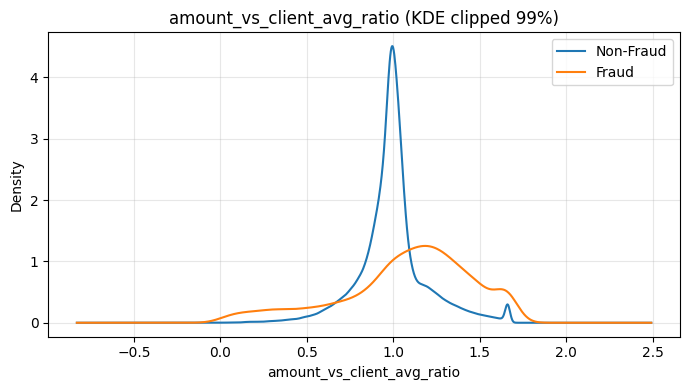

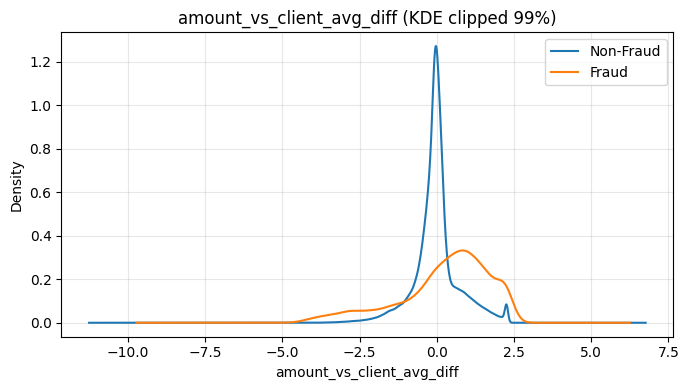

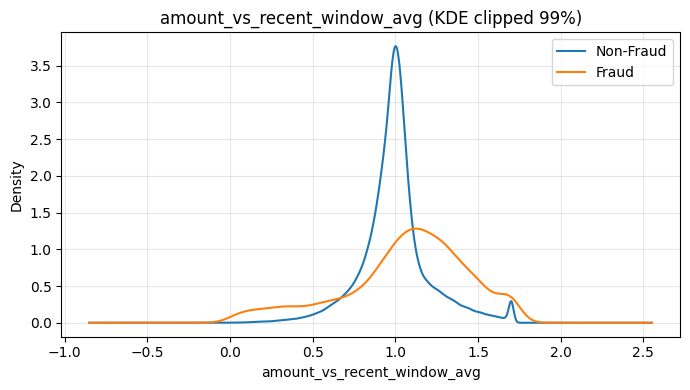

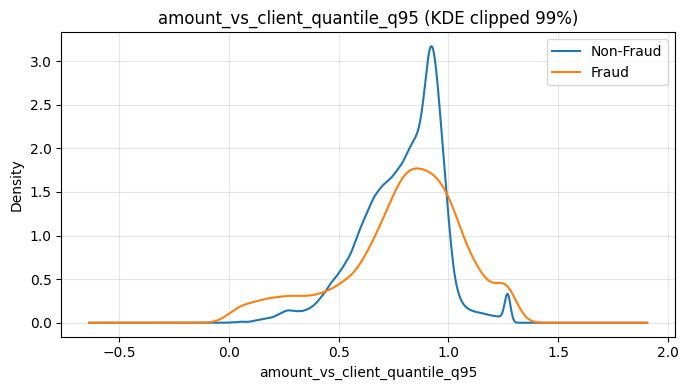

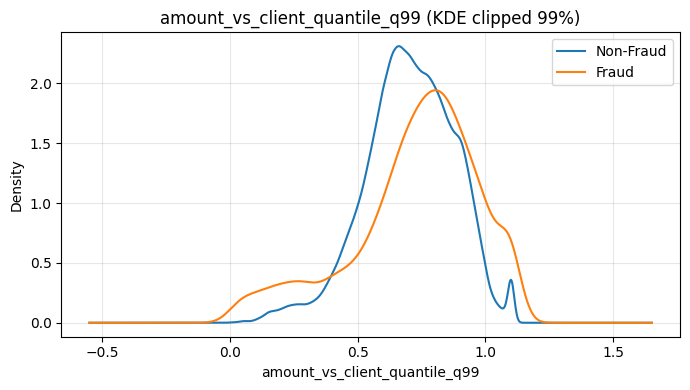

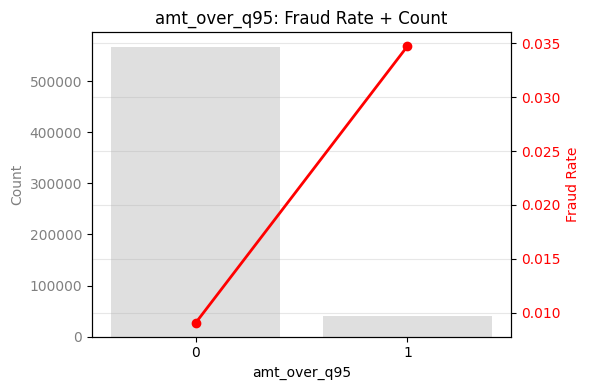

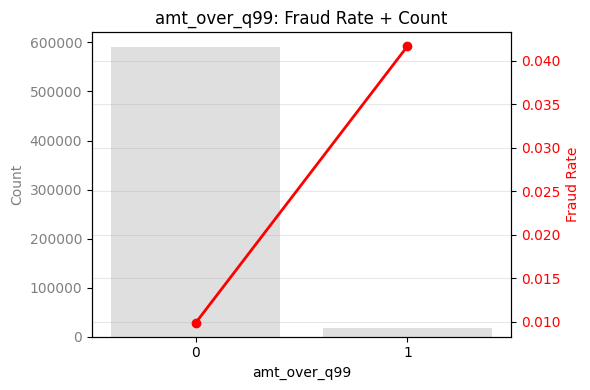

In [17]:
cols_sum = [
    "amount_vs_client_avg_ratio",
    "amount_vs_client_avg_diff",
    "amount_vs_recent_window_avg",
    "amount_vs_client_quantile_q95",
    "amount_vs_client_quantile_q99",
    "amt_over_q95",
    "amt_over_q99"
]

for col in cols_sum:
    plot_feature_by_type(df, col, y="fraud", clip_q=0.99)

- amount_vs_client_avg_ratio -> ratio 높을수록 fraud
- amount_vs_client_avg_diff -> dff 클수록 fraud
- amount_vs_recent_window_avg -> 약간의 분포 차 _ avg에 비해 amount가 더 많을수록 fraud 확률 높아짐
- amount_vs_client_quantaile_q95,99 -> 해당 고객의 과거 상위 *% 금액 수준 조금 더 크면 fraud 확률 높아짐 _ flag도 마찬가지


In [18]:
rows_uni = []

for col in cols_sum:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_vs_client_avg_diff,0.480777,1.617330,1.663032e-245,0.040103,3.714982,60843
1,amount_vs_client_avg_ratio,1.027085,2.792912,4.533187e-245,0.039972,3.702801,60843
2,amount_vs_recent_window_avg,0.738622,2.093049,2.319020e-142,0.035682,3.305420,60843
3,amount_vs_client_quantile_q95,0.235566,1.265625,9.002427e-05,0.027185,2.518270,60843
4,amount_vs_client_quantile_q99,0.732223,2.079700,4.830779e-29,0.022484,2.082826,60843
5,amt_over_q95,1.370876,3.938799,0.000000e+00,0.010795,1.000000,608430
6,amt_over_q99,1.470435,4.351126,6.374711e-293,0.010795,1.000000,608430


In [ ]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols_sum:
    if col in BASELINE:
        
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,amount_vs_client_avg_ratio,OK,-0.210055,0.810540,9.424449e-03,0.010795,0.041944,3.885505,-0.000279,-0.025883,60843
1,amt_over_q99,OK,0.359218,1.432210,9.443915e-14,0.010795,0.041336,3.829172,-0.000888,-0.082217,60843
2,amount_vs_client_quantile_q99,OK,-7.107725,0.000819,0.000000e+00,0.010795,0.041106,3.807856,-0.001118,-0.103532,60843
3,amount_vs_recent_window_avg,OK,-1.954616,0.141619,2.039069e-89,0.010795,0.040333,3.736297,-0.001890,-0.175091,60843
4,amount_vs_client_quantile_q95,OK,-6.147925,0.002138,0.000000e+00,0.010795,0.040202,3.724117,-0.002022,-0.187272,60843
5,amt_over_q95,OK,0.530896,1.700454,2.108944e-43,0.010795,0.040169,3.721072,-0.002054,-0.190317,60843
6,amount_vs_client_avg_diff,OK,-0.771451,0.462342,1.255073e-143,0.010795,0.038690,3.584044,-0.003534,-0.327345,60843


### Interval Features

In [31]:
# 1) 이전 거래 시점
df["prev_tx_time"] = df.groupby("client_id")["date"].shift(1)

# 2) 초 단위 간격
df["seconds_since_prev_tx"] = (
    (df["date"] - df["prev_tx_time"]).dt.total_seconds()
)

# 첫 거래는 간격 없음 → 큰 값으로 처리 (중립)
df["seconds_since_prev_tx"] = df["seconds_since_prev_tx"].fillna(0)

# 로그 변환
df["log_interval"] = np.log1p(df["seconds_since_prev_tx"])

In [32]:
# 과거값 shift
df["log_interval_shift"] = df.groupby("client_id")["log_interval"].shift(1)

# 누적합
df["interval_cumsum"] = (
    df["log_interval_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

# 과거 개수
df["interval_cnt_past"] = df.groupby("client_id").cumcount()

# 과거 평균
df["client_avg_interval_prev"] = np.where(
    df["interval_cnt_past"] > 0,
    df["interval_cumsum"] / df["interval_cnt_past"],
    df["log_interval"] 
)


In [33]:
# ratio
df["interval_ratio"] = (
    df["log_interval"] /
    (df["client_avg_interval_prev"] + 1e-6)
)

# deviation (z-score 방식)
df["log_interval_dev"] = (
    df["log_interval"] -
    df["client_avg_interval_prev"]
)

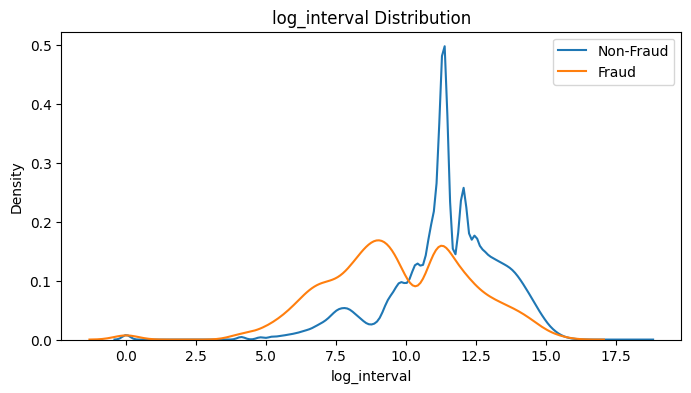

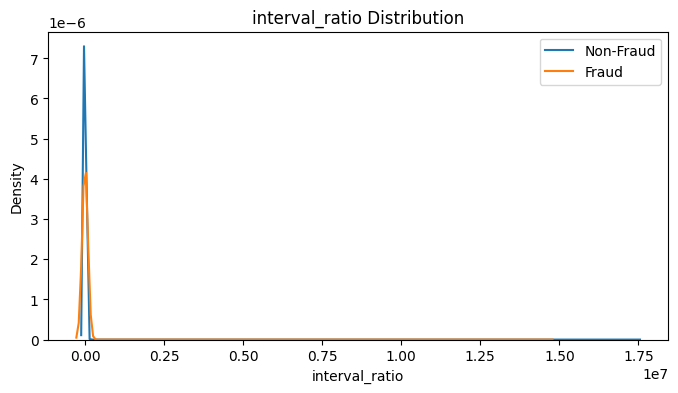

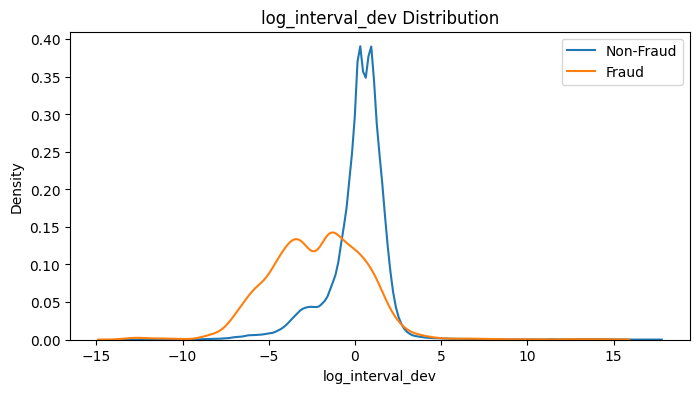

In [34]:
sample = df.copy()

features = [
    "log_interval",
    "interval_ratio",
    "log_interval_dev"
]

for col in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sample[sample["fraud"]==0][col], label="Non-Fraud")
    sns.kdeplot(sample[sample["fraud"]==1][col], label="Fraud")
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()


In [35]:
cols = [
    "seconds_since_prev_tx",
    "client_avg_interval_prev",
    "interval_ratio",
    "log_interval_dev"
]

In [36]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)


display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,log_interval_dev,-4.276907e-01,0.652013,0.000000e+00,0.053219,4.929963,60843
1,interval_ratio,-7.049454e-09,1.000000,7.555209e-01,0.051559,4.776188,60843
2,seconds_since_prev_tx,-8.335428e-07,0.999999,6.266262e-97,0.035169,3.257940,60962
3,client_avg_interval_prev,5.241944e-01,1.689097,0.000000e+00,0.023010,2.131547,60843


In [37]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,log_interval_dev,OK,-4.170605e-01,0.658981,0.000000e+00,0.010795,0.062094,5.752132,0.019871,1.840743,60843
1,seconds_since_prev_tx,OK,-1.243379e-06,0.999999,1.261430e-173,0.010795,0.053449,4.951279,0.011226,1.039890,60843
2,interval_ratio,OK,-2.970384e-08,1.000000,1.980713e-01,0.010795,0.042240,3.912911,0.000016,0.001523,60843
3,client_avg_interval_prev,OK,3.685179e-01,1.445590,2.092756e-177,0.010795,0.037967,3.517052,-0.004257,-0.394336,60843


### MCC Behavioral Feature

In [56]:
df = df.sort_values(["client_id", "date"]).copy()
df["mcc"] = df["mcc"].astype("category")
g = df.groupby("client_id")["mcc"]

df["client_mcc_prev"] = g.shift(1)
df["client_mcc_match_last1"] = (df["mcc"] == df["client_mcc_prev"]).fillna(False).astype("int8")

In [57]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["client_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["client_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 현재 mcc가 몇 번 반복됐는지 (0~3 / 0~5)
df["client_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["client_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["client_mcc_repeat_ratio_last3"] = (df["client_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["client_mcc_repeat_ratio_last5"] = (df["client_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [58]:
df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()
df["client_mcc_is_new"] = (df["client_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_4012138/2995284639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()


In [59]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

# 최근 5개에서 바뀐 횟수
# (prev5->prev4, prev4->prev3, prev3->prev2, prev2->prev1) 중 바뀐 횟수
chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["client_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))

In [60]:
g = df.groupby("card_id")["mcc"]

df["card_mcc_prev"] = g.shift(1)
df["card_mcc_match_last1"] = (df["mcc"] == df["card_mcc_prev"]).fillna(False).astype("int8")

In [61]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["card_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["card_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 '현재 mcc'가 몇 번 반복됐는지 (0~3 / 0~5)
df["card_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["card_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["card_mcc_repeat_ratio_last3"] = (df["card_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["card_mcc_repeat_ratio_last5"] = (df["card_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [62]:
df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()
df["card_mcc_is_new"] = (df["card_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_4012138/2656056192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()


In [63]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["card_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))


In [64]:
def analyze_feature(df, feature):
    
    # Fraud rate 테이블
    table = (
        df.groupby(feature)["fraud"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "fraud_rate"})
    )
    
    # baseline 계산
    baseline = table["fraud_rate"].min()
    table["uplift"] = table["fraud_rate"] / baseline
    
    display(table.round(4))
    
    plt.figure(figsize=(5,4))
    table["fraud_rate"].plot(kind="bar")
    plt.title(f"{feature} vs Fraud Rate")
    plt.ylabel("Fraud Rate")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


In [65]:
mcc_features = [
    "client_mcc_match_last1",
    "client_mcc_seen_last3",
    "client_mcc_seen_last5",
    "client_mcc_repeat_cnt_last3",
    "client_mcc_repeat_cnt_last5",
    "client_mcc_is_new",
    "client_mcc_change_cnt_last5",
    
    "card_mcc_match_last1",
    "card_mcc_seen_last3",
    "card_mcc_seen_last5",
    "card_mcc_repeat_cnt_last3",
    "card_mcc_repeat_cnt_last5",
    "card_mcc_is_new",
    "card_mcc_change_cnt_last5",
]


========== client_mcc_match_last1 ==========


,fraud_rate,count,uplift
client_mcc_match_last1,,,
0,0.0223,264579,11.3461
1,0.0020,343851,1.0000


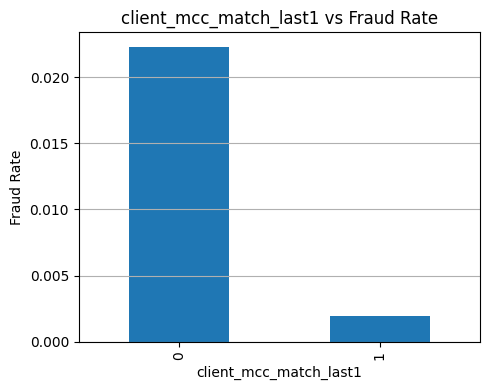


========== client_mcc_seen_last3 ==========


,fraud_rate,count,uplift
client_mcc_seen_last3,,,
0,0.0319,164655,10.8281
1,0.0029,443775,1.0000


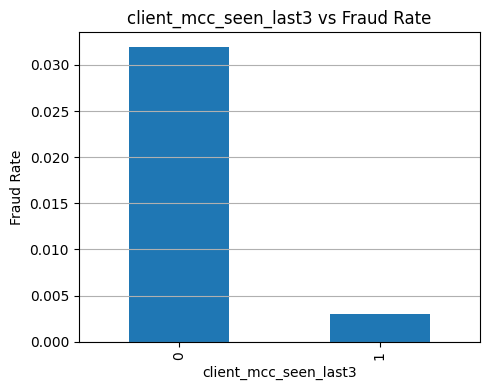


========== client_mcc_seen_last5 ==========


,fraud_rate,count,uplift
client_mcc_seen_last5,,,
0,0.0378,129231,10.7974
1,0.0035,479199,1.0000


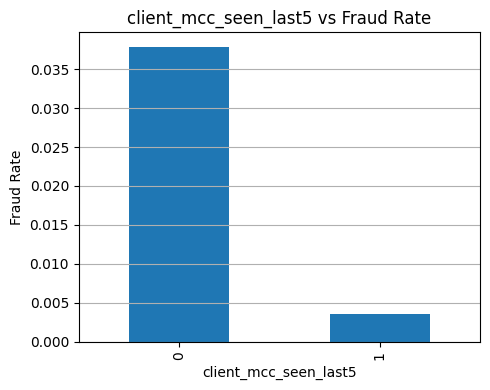


========== client_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last3,,,
0,0.0319,164655,572.7933
1,0.0109,100209,196.1433
2,0.0018,110428,32.4803
3,0.0001,233138,1.0000


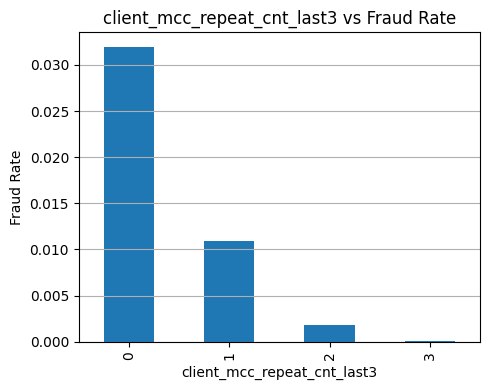


========== client_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last5,,,
0,0.0378,129231,7074.7516
1,0.0149,81841,2794.5597
2,0.0063,55697,1171.7946
3,0.0017,54027,314.9839
4,0.0001,100627,27.8763
5,0.0000,187007,1.0000


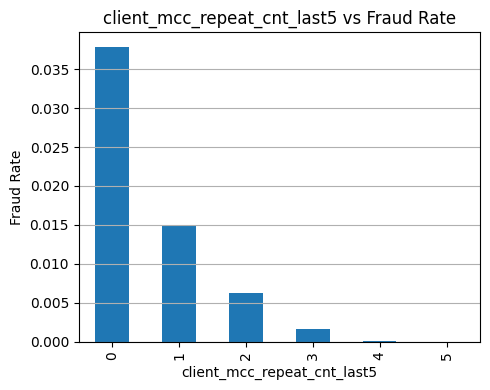


========== client_mcc_is_new ==========


,fraud_rate,count,uplift
client_mcc_is_new,,,
0,0.0049,591464,1.0000
1,0.2159,16966,43.9582


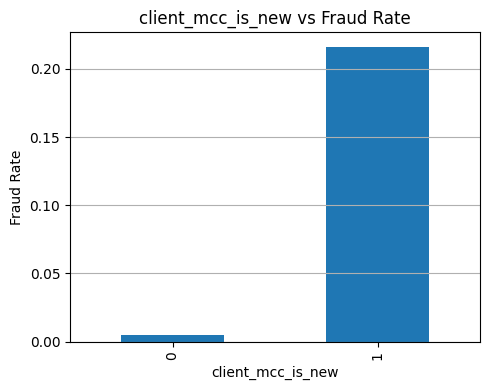


========== client_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_change_cnt_last5,,,
0,0.0006,207304,1.0000
1,0.0041,59362,6.6795
2,0.0062,123838,10.1901
3,0.0168,116700,27.6044
4,0.0343,101226,56.4969


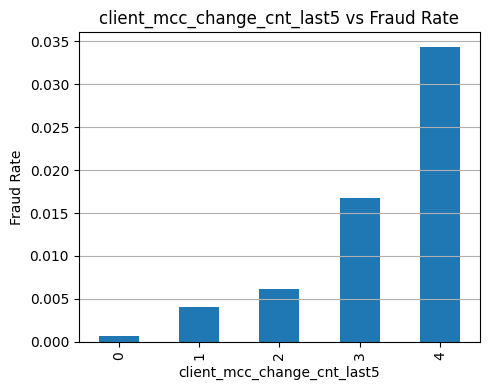


========== card_mcc_match_last1 ==========


,fraud_rate,count,uplift
card_mcc_match_last1,,,
0,0.0224,262926,11.2857
1,0.0020,345504,1.0000


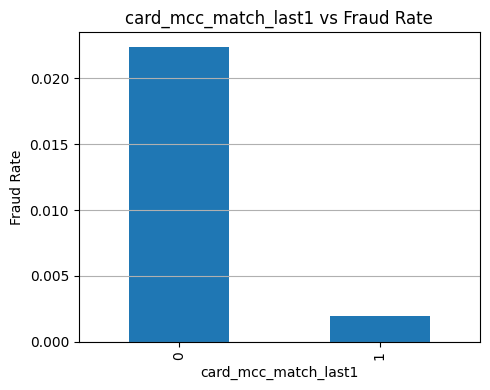


========== card_mcc_seen_last3 ==========


,fraud_rate,count,uplift
card_mcc_seen_last3,,,
0,0.0316,165349,10.3768
1,0.0030,443081,1.0000


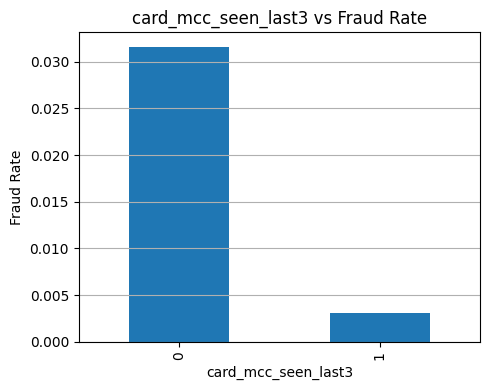


========== card_mcc_seen_last5 ==========


,fraud_rate,count,uplift
card_mcc_seen_last5,,,
0,0.0372,131085,10.4857
1,0.0035,477345,1.0000


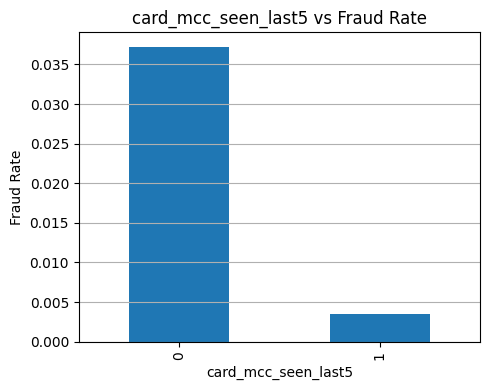


========== card_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last3,,,
0,0.0316,165349,494.9964
1,0.0114,98697,178.4058
2,0.0019,109191,30.1554
3,0.0001,235193,1.0000


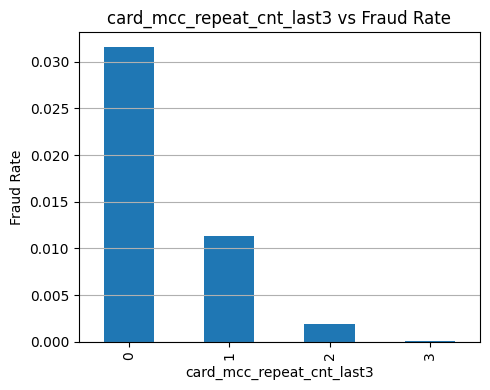


========== card_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last5,,,
0,0.0372,131085,inf
1,0.0152,80755,inf
2,0.0066,55327,inf
3,0.0015,53269,inf
4,0.0002,98894,inf
5,0.0000,189100,NaN


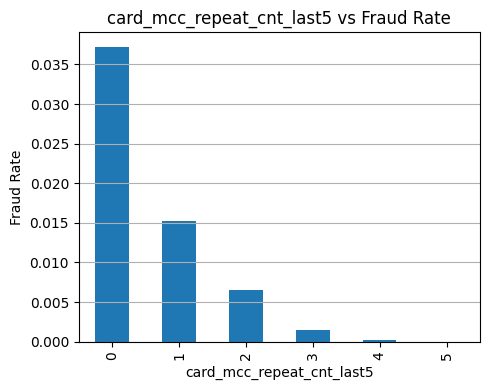


========== card_mcc_is_new ==========


,fraud_rate,count,uplift
card_mcc_is_new,,,
0,0.0043,573756,1.0000
1,0.1180,34674,27.3115


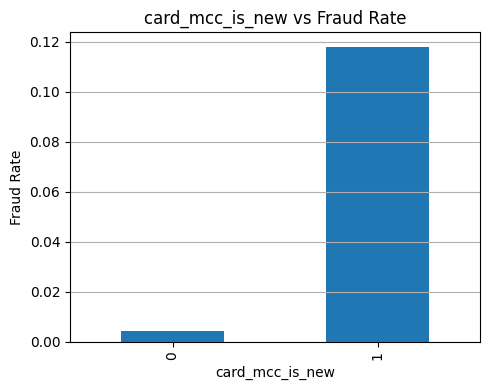


========== card_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_change_cnt_last5,,,
0,0.0006,209091,1.0000
1,0.0043,59160,7.0408
2,0.0059,121493,9.7840
3,0.0167,113499,27.5609
4,0.0339,105187,55.8150


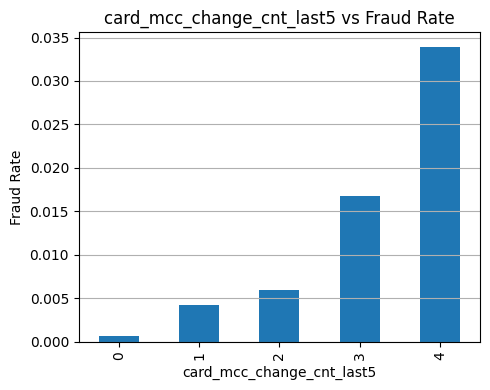

In [66]:
for f in mcc_features:
    print(f"\n========== {f} ==========")
    analyze_feature(df, f)


In [67]:
rows_uni = []

for col in mcc_features:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_mcc_repeat_cnt_last5,-1.083075,0.338553,0.0,0.037831,3.504538,129231
1,client_mcc_seen_last5,-2.414360,0.089425,0.0,0.037831,3.504538,129231
2,card_mcc_repeat_cnt_last5,-1.066509,0.344208,0.0,0.037190,3.445078,131085
3,card_mcc_seen_last5,-2.384357,0.092148,0.0,0.037190,3.445078,131085
4,client_mcc_change_cnt_last5,0.881025,2.413373,0.0,0.034339,3.181011,101226
5,card_mcc_change_cnt_last5,0.877793,2.405585,0.0,0.033902,3.140485,105187
6,client_mcc_seen_last3,-2.411649,0.089667,0.0,0.031940,2.958733,164655
7,client_mcc_repeat_cnt_last3,-1.445247,0.235688,0.0,0.031940,2.958733,164655
8,card_mcc_repeat_cnt_last3,-1.414517,0.243043,0.0,0.031570,2.924465,165349
9,card_mcc_seen_last3,-2.368601,0.093612,0.0,0.031570,2.924465,165349


In [68]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in mcc_features:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_mcc_is_new,OK,3.277820,26.517909,0.0,0.010795,0.075818,7.023447,0.033595,3.112058,60843
1,client_mcc_is_new,OK,3.886426,48.736400,0.0,0.010795,0.072728,6.737211,0.030505,2.825822,60843
2,client_mcc_repeat_cnt_last5,OK,-1.077757,0.340358,0.0,0.010795,0.049669,4.601096,0.007445,0.689708,60843
3,card_mcc_repeat_cnt_last5,OK,-1.061068,0.346086,0.0,0.010795,0.049389,4.575213,0.007166,0.663825,60843
4,client_mcc_seen_last5,OK,-2.294327,0.100829,0.0,0.010795,0.049028,4.541717,0.006804,0.630329,60843
5,card_mcc_seen_last5,OK,-2.257914,0.104568,0.0,0.010795,0.048699,4.511267,0.006476,0.599878,60843
6,card_mcc_change_cnt_last5,OK,0.829549,2.292284,0.0,0.010795,0.047894,4.436663,0.005670,0.525274,60843
7,client_mcc_change_cnt_last5,OK,0.824214,2.280089,0.0,0.010795,0.047499,4.400122,0.005276,0.488733,60843
8,client_mcc_repeat_cnt_last3,OK,-1.415864,0.242716,0.0,0.010795,0.046316,4.290499,0.004093,0.379111,60843
9,client_mcc_seen_last3,OK,-2.289103,0.101357,0.0,0.010795,0.046250,4.284409,0.004027,0.373021,60843


### Merchant Novelty & Switching Block

**client_merchant_is_new / card_merchant_is_new**

In [47]:
df["client_merchant_is_new"] = (
    df.groupby(["client_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

df["card_merchant_is_new"] = (
    df.groupby(["card_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

**merchant_change_cnt_last5 (최근 5건에서 merchant가 몇 번 바뀌었는지)**

In [ ]:
prev_merchant = df.groupby("card_id", sort=False)["merchant_id"].shift(1)

df["merchant_changed"] = (
    df["merchant_id"].ne(prev_merchant)      # 직전과 다르면 True
    .fillna(True)                            # 첫 거래는 변경
    .astype("int8")
)

# 2) 최근 5건에서 변경 횟수
df["merchant_change_cnt_last5"] = (
    df.groupby("card_id", sort=False)["merchant_changed"]
      .rolling(window=5, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
      .astype("int8")
)

df.drop(columns=["merchant_changed"], inplace=True)

**merchant_is_new × mcc_is_new / has_error**

In [49]:
# merchant_is_new 정의(카드 기준)
df["merchant_is_new"] = df["card_merchant_is_new"].astype("int8")

# merchant_is_new × mcc_is_new 
if "card_mcc_is_new" in df.columns:
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"].astype("int8") * df["card_mcc_is_new"].astype("int8")
    ).astype("int8")
else:
    # 없으면 대체: card 단위로 mcc 첫 등장 여부 생성
    df["card_mcc_is_new"] = (
        df.groupby(["card_id", "mcc"], sort=False).cumcount().eq(0).astype("int8")
    )
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"] * df["card_mcc_is_new"]
    ).astype("int8")

# merchant_is_new × has_error
df["merchant_is_new_x_has_error"] = (
    df["merchant_is_new"].astype("int8") * df["has_error"].astype("int8")
).astype("int8")

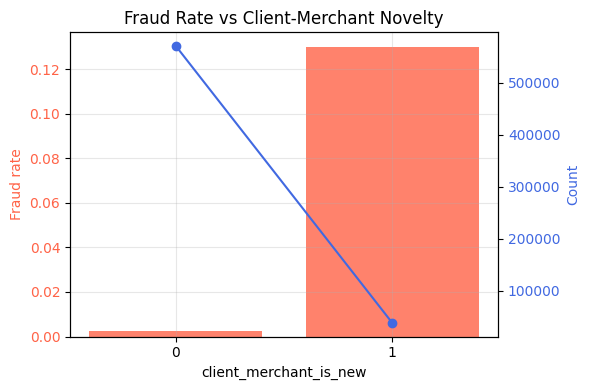

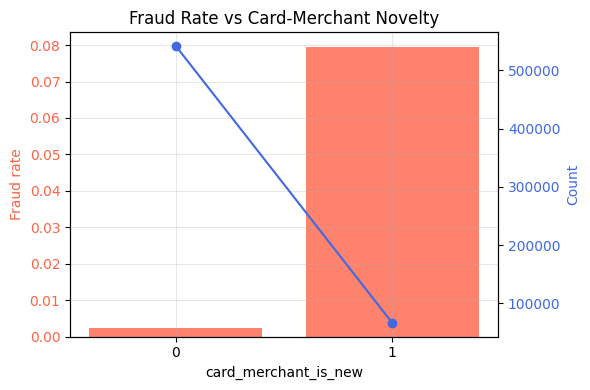

In [50]:
def plot_rate_and_count_by_flag(df, flag_col, title):
    g = df.groupby(flag_col)["fraud"].agg(rate="mean", cnt="size")
    fig, ax1 = plt.subplots(figsize=(6,4))

    # fraud rate (bar)
    ax1.bar(g.index.astype(str), g["rate"], color="tomato", alpha=0.8)
    ax1.set_ylabel("Fraud rate", color="tomato")
    ax1.set_xlabel(flag_col)
    ax1.set_title(title)
    ax1.tick_params(axis="y", labelcolor="tomato")
    ax1.grid(True, alpha=0.3)

    # count (line)
    ax2 = ax1.twinx()
    ax2.plot(g.index.astype(str), g["cnt"], color="royalblue", marker="o")
    ax2.set_ylabel("Count", color="royalblue")
    ax2.tick_params(axis="y", labelcolor="royalblue")

    plt.tight_layout()
    plt.show()

plot_rate_and_count_by_flag(df, "client_merchant_is_new", 
                            "Fraud Rate vs Client-Merchant Novelty")

plot_rate_and_count_by_flag(df, "card_merchant_is_new", 
                            "Fraud Rate vs Card-Merchant Novelty")


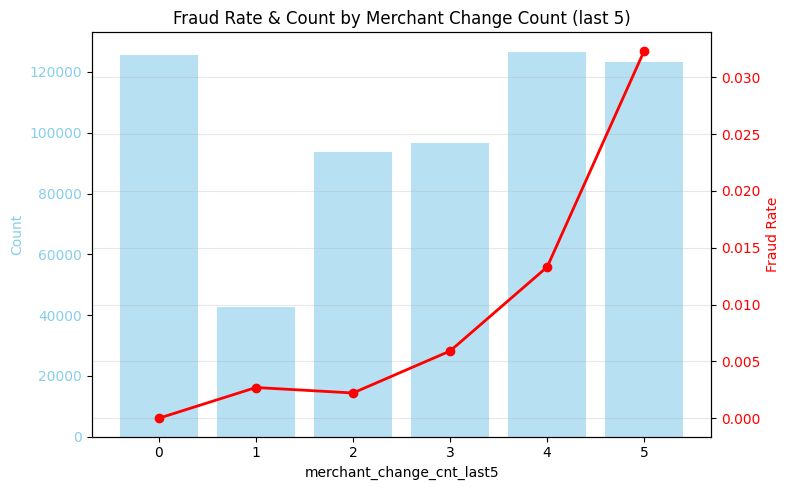

In [51]:
tmp = (
    df.groupby("merchant_change_cnt_last5")["fraud"]
      .agg(rate="mean", cnt="size")
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8,5))

# --- 1) Count (막대) ---
ax1.bar(
    tmp["merchant_change_cnt_last5"].astype(str),
    tmp["cnt"],
    color="skyblue",
    alpha=0.6,
    label="Count"
)
ax1.set_xlabel("merchant_change_cnt_last5")
ax1.set_ylabel("Count", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")

# --- 2) Fraud Rate (선) ---
ax2 = ax1.twinx()
ax2.plot(
    tmp["merchant_change_cnt_last5"].astype(str),
    tmp["rate"],
    color="red",
    marker="o",
    linewidth=2,
    label="Fraud Rate"
)
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Fraud Rate & Count by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

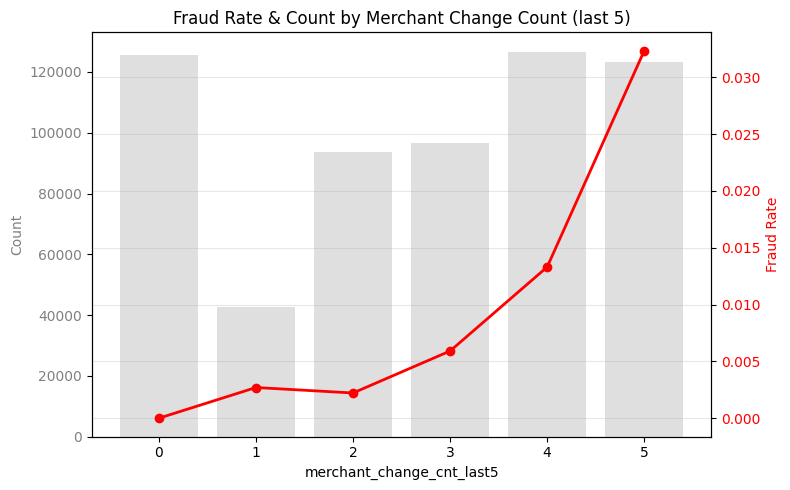

In [52]:
tmp = (
    df.groupby("merchant_change_cnt_last5")["fraud"]
      .agg(rate="mean", cnt="size")
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8,5))

x = tmp["merchant_change_cnt_last5"]

# --- 1) Count (뒤에 투명 막대) ---
ax1.bar(
    x,
    tmp["cnt"],
    color="gray",
    alpha=0.25
)
ax1.set_ylabel("Count", color="gray")
ax1.tick_params(axis='y', labelcolor="gray")

# --- 2) Fraud Rate (앞에 선 그래프) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    tmp["rate"],
    marker="o",
    linewidth=2,
    color="red"
)
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax1.set_xlabel("merchant_change_cnt_last5")
plt.title("Fraud Rate & Count by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
cols = ["merchant_is_new_x_has_error",
        "merchant_is_new_x_mcc_is_new",
        "merchant_change_cnt_last5",
        "card_merchant_is_new",
        "client_merchant_is_new"]

In [54]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,card_merchant_is_new,3.606242,36.827398,0.0,0.079523,7.366696,66647
1,merchant_change_cnt_last5,0.881115,2.413589,0.0,0.032337,2.995584,123325
2,merchant_is_new_x_has_error,2.761005,15.815731,0.0,0.010795,1.000000,608430
3,merchant_is_new_x_mcc_is_new,3.427844,30.810149,0.0,0.010795,1.000000,608430
4,client_merchant_is_new,4.001996,54.707253,0.0,0.010795,1.000000,608430


In [55]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_merchant_is_new,OK,4.060571,58.007436,0.000000e+00,0.010795,0.085992,7.965895,0.043768,4.054507,60843
1,card_merchant_is_new,OK,3.574467,35.675615,0.000000e+00,0.010795,0.080469,7.454324,0.038246,3.542935,60843
2,merchant_is_new_x_mcc_is_new,OK,3.277070,26.498023,0.000000e+00,0.010795,0.075802,7.021924,0.033578,3.110536,60843
3,merchant_change_cnt_last5,OK,0.847215,2.333140,0.000000e+00,0.010795,0.049340,4.570646,0.007117,0.659257,60843
4,merchant_is_new_x_has_error,OK,3.139197,23.085321,1.617344e-97,0.010795,0.043933,4.069732,0.001709,0.158343,60843


### Velocity Feaures

In [38]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)

# numpy index 준비
n = len(df)

client_tx_1h = np.zeros(n, dtype=np.int32)
card_tx_1h = np.zeros(n, dtype=np.int32)

각 거래 시점 기준, 최근 1시간 내에 같은 고객이 몇 번 거래했는가?

In [39]:
for cid, idx in df.groupby("client_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    # 누적 거래 번호
    cum = np.arange(len(g))
    
    # 1시간 전 timestamp
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    client_tx_1h[idx] = cum - left + 1

In [40]:
df["client_tx_1h"] = client_tx_1h

In [41]:
df["client_tx_1h_shift"] = df.groupby("client_id")["client_tx_1h"].shift(1)

# 지금까지의 (과거) 1시간 거래 수 총합
df["client_tx_1h_cumsum"] = (
    df["client_tx_1h_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

# 과거 거래 개수
df["client_tx_cnt_past"] = df.groupby("client_id").cumcount()

# 과거 평균 계산
df["client_tx_1h_avg_prev"] = np.where(
    df["client_tx_cnt_past"] > 0,
    df["client_tx_1h_cumsum"] / df["client_tx_cnt_past"],
    df["client_tx_1h"]
)

In [42]:
# 현재 1시간 거래 수가 평소 평균 대비 몇 배인가? 
df["velocity_spike_ratio"] = (
    df["client_tx_1h"] /
    (df["client_tx_1h_avg_prev"] + 1e-6)
)

In [43]:
for cid, idx in df.groupby("card_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    cum = np.arange(len(g))
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    card_tx_1h[idx] = cum - left + 1

df["card_tx_1h"] = card_tx_1h

In [44]:
df["card_tx_1h_shift"] = df.groupby("card_id")["card_tx_1h"].shift(1)

df["card_tx_1h_cumsum"] = (
    df["card_tx_1h_shift"].fillna(0)
      .groupby(df["card_id"])
      .cumsum()
)

df["card_tx_cnt_past"] = df.groupby("card_id").cumcount()

df["card_tx_1h_avg_prev"] = np.where(
    df["card_tx_cnt_past"] > 0,
    df["card_tx_1h_cumsum"] / df["card_tx_cnt_past"],
    df["card_tx_1h"]
)

df["card_velocity_spike_ratio"] = (
    df["card_tx_1h"] /
    (df["card_tx_1h_avg_prev"] + 1e-6)
)

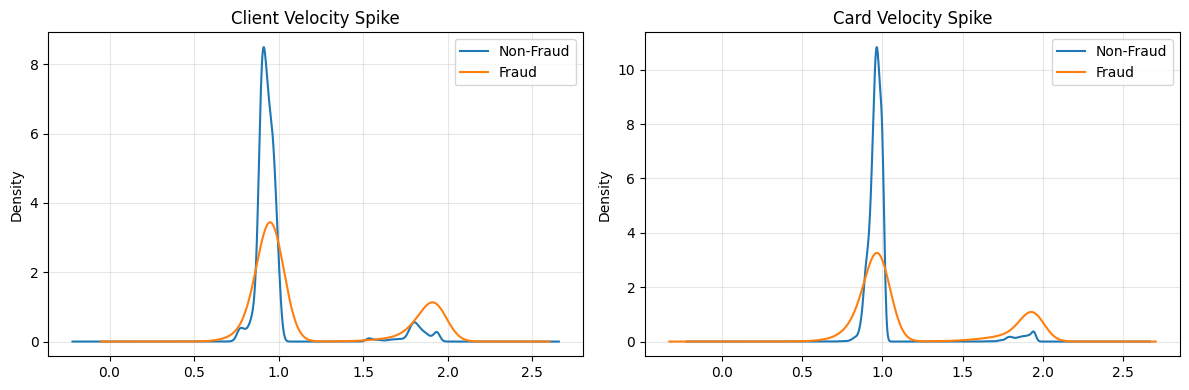

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Client
xmax = df["velocity_spike_ratio"].quantile(0.99)
df[df["fraud"]==0]["velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[0], label="Non-Fraud"
)
df[df["fraud"]==1]["velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[0], label="Fraud"
)
axes[0].set_title("Client Velocity Spike")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Card
xmax = df["card_velocity_spike_ratio"].quantile(0.99)
df[df["fraud"]==0]["card_velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[1], label="Non-Fraud"
)
df[df["fraud"]==1]["card_velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[1], label="Fraud"
)
axes[1].set_title("Card Velocity Spike")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

-> 딘독으로는 약할 수 있음

In [73]:
df["vel_x_error"] = (
    df["velocity_spike_ratio"] *
    df["has_error"]
)
df["vel_x_mcc_risk"] = (
    df["velocity_spike_ratio"] *
    df["mcc_risk_level"]
)
df["vel_x_high_mcc"] = (
    df["velocity_spike_ratio"] *
    (df["mcc_risk_level"] == 2).astype("int8")
)
df["vel_x_merchant_new"] = (
    df["velocity_spike_ratio"] *
    df["merchant_is_new"]
)
df["vel_x_client_mcc_new"] = (
    df["velocity_spike_ratio"] *
    df["client_mcc_is_new"]
)
df["vel_x_card_mcc_new"] = (
    df["velocity_spike_ratio"] *
    df["card_mcc_is_new"]
)
df["high_vel_flag"] = (
    df["velocity_spike_ratio"] >
    df["velocity_spike_ratio"].quantile(0.95)
).astype("int8")

df["high_vel_error"] = df["high_vel_flag"] * df["has_error"]
df["high_vel_new_mcc"] = df["high_vel_flag"] * df["client_mcc_is_new"]

In [74]:
cols = [
"client_tx_1h",
"client_tx_1h_avg_prev",
"velocity_spike_ratio",
"card_tx_1h",
"card_velocity_spike_ratio",
"vel_x_error",
"vel_x_mcc_risk",
"vel_x_high_mcc",
"vel_x_merchant_new",
"vel_x_client_mcc_new",
"vel_x_card_mcc_new",
"high_vel_flag",
"high_vel_error",
"high_vel_new_mcc"
]

rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,vel_x_merchant_new,3.151726,23.376387,0.000000e+00,0.077741,7.201583,60843
1,velocity_spike_ratio,1.569352,4.803536,0.000000e+00,0.028081,2.601323,80267
2,card_velocity_spike_ratio,1.980728,7.248018,0.000000e+00,0.023123,2.141979,136403
3,client_tx_1h_avg_prev,-6.012534,0.002448,2.511206e-114,0.018193,1.685333,60902
4,card_tx_1h,1.854879,6.390923,0.000000e+00,0.010795,1.000000,608430
5,client_tx_1h,1.274816,3.578041,0.000000e+00,0.010795,1.000000,608430
6,vel_x_error,0.441451,1.554961,9.652565e-26,0.010795,1.000000,608430
7,vel_x_mcc_risk,1.298931,3.665377,0.000000e+00,0.010795,1.000000,608430
8,vel_x_high_mcc,2.500497,12.188546,0.000000e+00,0.010795,1.000000,608430
9,vel_x_client_mcc_new,3.826549,45.903859,0.000000e+00,0.010795,1.000000,608430


In [75]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:

        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,vel_x_merchant_new,OK,3.100652,22.212421,0.000000e+00,0.010795,0.079631,7.376675,0.037408,3.465286,60843
1,vel_x_card_mcc_new,OK,2.991466,19.914864,0.000000e+00,0.010795,0.077626,7.190926,0.035403,3.279537,60843
2,vel_x_client_mcc_new,OK,3.677913,39.563739,0.000000e+00,0.010795,0.073944,6.849878,0.031721,2.938490,60843
3,high_vel_new_mcc,OK,6.858489,951.927961,0.000000e+00,0.010795,0.049669,4.601096,0.007445,0.689708,60843
4,card_tx_1h,OK,1.847435,6.343528,0.000000e+00,0.010795,0.049389,4.575213,0.007166,0.663825,60843
5,vel_x_mcc_risk,OK,1.157723,3.182679,0.000000e+00,0.010795,0.047795,4.427527,0.005572,0.516139,60843
6,card_velocity_spike_ratio,OK,1.930372,6.892074,0.000000e+00,0.010795,0.047532,4.403167,0.005309,0.491778,60843
7,vel_x_high_mcc,OK,2.142233,8.518436,0.000000e+00,0.010795,0.046513,4.308770,0.004290,0.397381,60843
8,high_vel_flag,OK,1.736204,5.675757,0.000000e+00,0.010795,0.046497,4.307247,0.004273,0.395859,60843
9,client_tx_1h,OK,1.326157,3.766541,0.000000e+00,0.010795,0.045790,4.241778,0.003567,0.330390,60843


# EDA — History Feature 분석 요약

## 1. 분석 구조

거래 이력 기반 피처를 5개 블록으로 설계하고 검증했다.

| 블록 | 피처 유형 |
|---|---|
| MCC 리스크 레벨 | 가맹점 업종 코드 기반 리스크 분류 |
| Fraud History | 고객/카드 단위 과거 사기 이력 |
| Amount Deviation | 고객 평균 대비 현재 금액 이탈 |
| Interval | 거래 간격 및 이탈도 |
| MCC Behavioral | 업종 반복·신규·전환 패턴 |
| Merchant Novelty | 가맹점 신규 방문 및 전환 패턴 |
| Velocity | 단시간 거래 집중도 |

---

## 2. MCC 리스크 레벨 (`mcc_risk_level`)

로지스틱 회귀 기반 MCC dummy 분석으로 업종별 계수를 추출한 뒤, 리스크 구간을 3단계로 분류했다.

| 레벨 | MCC 코드 | 거래 수 |
|---|---|---|
| 0 (저위험/일반) | 나머지 | 549,993 |
| 1 (중위험) | 5193, 5311, 7996 | 52,002 |
| 2 (고위험) | 5732, 5712, 5045, 5816, 5651, 4411 | 6,435 |

고위험 MCC(레벨 2)는 전자제품, 가구, 컴퓨터 도매, 의류 등 고단가 내구재 중심이다.

---

## 3. Fraud History

### 3-1. 피처 설계

고객(client)과 카드(card) 단위로 직전 1건 및 최근 3건 누적을 각각 생성했다.

- `client_fraud_last1`: 고객의 직전 거래 사기 여부 (0/1)
- `card_fraud_last1`: 카드의 직전 거래 사기 여부 (0/1)
- `client_fraud_last3`: 고객 최근 3건 중 사기 건수 (0~3)
- `card_fraud_last3`: 카드 최근 3건 중 사기 건수 (0~3)

### 3-2. 단변량 성능

OR이 극단적으로 높다. `card_fraud_last1`의 OR은 **1,557** — 직전 거래가 사기였으면 현재 거래도 사기일 확률이 압도적으로 높다. 그러나 단독 Top-decile Lift는 모두 1.0으로 측정된다. 이는 해당 이력이 있는 케이스가 전체의 극소수라 Top-decile에 집중되지 않는 구조다.

### 3-3. Add-one 다변량 검증 (Baseline 대비 Δ Lift)

| Feature | Δ Lift | Top-decile Rate |
|---|---|---|
| **card_fraud_last3** | **+4.831** | 9.44% |
| **client_fraud_last3** | **+4.782** | 9.38% |
| **card_fraud_last1** | **+4.629** | 9.22% |
| **client_fraud_last1** | **+4.435** | 9.01% |

Baseline 3.91 대비 최대 +4.83으로 **이 분석 전체에서 단일 피처 기여 최상위**다.

> **전체 KEEP.** 4개 모두 압도적인 기여. last3이 last1보다 안정적으로 높으나, last1은 직전 사기의 즉각적 신호로 보완 역할.

---

## 4. Amount Deviation (고객 평균 대비 금액 이탈)

### 4-1. 피처 설계

| 피처 | 설명 |
|---|---|
| `amount_vs_client_avg_ratio` | 현재 금액 / 고객 전체 과거 평균 |
| `amount_vs_client_avg_diff` | 현재 금액 - 고객 전체 과거 평균 |
| `amount_vs_recent_window_avg` | 현재 금액 / 최근 10건 평균 |
| `amount_vs_client_quantile_q95` | 현재 금액 / 고객 과거 q95 |
| `amount_vs_client_quantile_q99` | 현재 금액 / 고객 과거 q99 |
| `amt_over_q95` | 현재 금액이 과거 q95 초과 여부 |
| `amt_over_q99` | 현재 금액이 과거 q99 초과 여부 |

### 4-2. 단변량 성능

| Feature | OR | Top-decile Lift |
|---|---|---|
| amount_vs_client_avg_diff | 1.62 | **3.71** |
| amount_vs_client_avg_ratio | 2.79 | **3.70** |
| amount_vs_recent_window_avg | 2.09 | 3.31 |
| amount_vs_client_quantile_q95 | 1.27 | 2.52 |
| amount_vs_client_quantile_q99 | 2.08 | 2.08 |

### 4-3. Add-one 다변량 검증

**모든 Amount Deviation 피처가 Baseline 대비 Δ Lift 음수** — 즉 Baseline의 `log_abs_amount`, `amount_income_ratio`, `amount_limit_ratio`에 이미 금액 이탈 신호가 충분히 담겨 있어 추가 기여가 없다.

| Feature | Δ Lift |
|---|---|
| amount_vs_client_avg_ratio | **-0.026** |
| amt_over_q99 | -0.082 |
| amount_vs_client_quantile_q99 | -0.104 |
| amount_vs_recent_window_avg | -0.175 |
| amount_vs_client_quantile_q95 | -0.187 |
| amt_over_q95 | -0.190 |
| amount_vs_client_avg_diff | **-0.327** |

> **전체 DROP.** 단독으로는 유의하지만 Baseline과 완전 중복. 추가 시 오히려 성능 저하.

---

## 5. Interval (거래 간격)

### 5-1. 피처 설계

| 피처 | 설명 |
|---|---|
| `seconds_since_prev_tx` | 직전 거래와의 간격 (초) |
| `log_interval` | log1p 변환 간격 |
| `client_avg_interval_prev` | 고객 과거 평균 간격 |
| `interval_ratio` | 현재 간격 / 고객 과거 평균 간격 |
| `log_interval_dev` | 현재 간격 - 고객 과거 평균 간격 |

### 5-2. 단변량 성능

| Feature | Top-decile Lift |
|---|---|
| **log_interval_dev** | **4.93** |
| interval_ratio | 4.78 |
| seconds_since_prev_tx | 3.26 |
| client_avg_interval_prev | 2.13 |

`log_interval_dev`(현재 간격이 평소보다 얼마나 짧은가)가 가장 강력하다. 평소보다 짧은 간격 = 거래 집중 = 고위험.

### 5-3. Add-one 다변량 검증 (Baseline 대비 Δ Lift)

| Feature | Δ Lift |
|---|---|
| **log_interval_dev** | **+1.841** |
| **seconds_since_prev_tx** | **+1.040** |
| interval_ratio | +0.002 (p=0.198, 유의하지 않음) |
| client_avg_interval_prev | **-0.394** (오히려 악화) |

> **`log_interval_dev` KEEP** — Baseline 대비 Δ Lift +1.84로 단일 피처 기여 2위. **`seconds_since_prev_tx` KEEP** — 추가 +1.04. **`interval_ratio` DROP** (유의하지 않음). **`client_avg_interval_prev` DROP** (성능 악화).

---

## 6. MCC Behavioral (업종 행동 패턴)

### 6-1. 피처 설계 및 segment 분석

클라이언트/카드 단위로 MCC 반복·신규·전환 패턴을 생성했다.

**`client_mcc_is_new` / `card_mcc_is_new`**: 해당 고객/카드가 이 업종에 처음 거래하는 경우.

| Feature | 신규(=1) Fraud Rate | Uplift |
|---|---|---|
| client_mcc_is_new=1 | **21.6%** | **43.96×** |
| card_mcc_is_new=1 | **11.8%** | **27.31×** |

**`client_mcc_change_cnt_last5`**: 최근 5건의 MCC 전환 횟수.

| 전환 횟수 | Fraud Rate | Uplift |
|---|---|---|
| 0 | 0.06% | 1.00 |
| 1 | 0.41% | 6.68 |
| 2 | 0.62% | 10.19 |
| 3 | 1.68% | 27.60 |
| **4** | **3.43%** | **56.50** |

**`client_mcc_repeat_cnt_last5`**: 최근 5건 중 현재 MCC 등장 횟수. 반복 횟수가 많을수록 안전(역방향).

| 반복 횟수 | Fraud Rate |
|---|---|
| 0 | 3.78% |
| 3 | 0.17% |
| 5 | 0.00% |

### 6-2. Add-one 다변량 검증 (Baseline 대비 Δ Lift)

| Feature | Δ Lift |
|---|---|
| **card_mcc_is_new** | **+3.112** |
| **client_mcc_is_new** | **+2.826** |
| client_mcc_repeat_cnt_last5 | +0.690 |
| card_mcc_repeat_cnt_last5 | +0.664 |
| client_mcc_seen_last5 | +0.630 |
| card_mcc_seen_last5 | +0.599 |
| card_mcc_change_cnt_last5 | +0.525 |
| client_mcc_change_cnt_last5 | +0.489 |
| client_mcc_repeat_cnt_last3 | +0.379 |
| card_mcc_repeat_cnt_last3 | +0.359 |
| client/card_mcc_match_last1 | +0.161 / +0.165 |

> **`card_mcc_is_new`, `client_mcc_is_new` KEEP** — add-one 최상위. **`client_mcc_repeat_cnt_last5`, `card_mcc_repeat_cnt_last5` KEEP** — 반복 횟수는 연속 정보를 담아 seen/match보다 정보량 높음. **`card_mcc_change_cnt_last5` KEEP** — 연속 전환 카운트. 나머지 중복/열위 피처 DROP.

---

## 7. Merchant Novelty & Switching

### 7-1. 피처 설계

| 피처 | 설명 |
|---|---|
| `client_merchant_is_new` | 고객이 이 가맹점에 처음 방문 |
| `card_merchant_is_new` | 카드로 이 가맹점에 처음 방문 |
| `merchant_change_cnt_last5` | 최근 5건 가맹점 변경 횟수 |
| `merchant_is_new_x_mcc_is_new` | 가맹점 신규 × MCC 신규 교차항 |
| `merchant_is_new_x_has_error` | 가맹점 신규 × 오류 발생 교차항 |

### 7-2. Segment 분석

| Feature | 신규(=1) Fraud Rate |
|---|---|
| client_merchant_is_new=1 | — (segment 미표시) |
| card_merchant_is_new=1 | **7.95%** (단변량 Top-decile Lift 7.37) |

### 7-3. Add-one 다변량 검증 (Baseline 대비 Δ Lift)

| Feature | Δ Lift |
|---|---|
| **client_merchant_is_new** | **+4.055** |
| **card_merchant_is_new** | **+3.543** |
| **merchant_is_new_x_mcc_is_new** | **+3.111** |
| merchant_change_cnt_last5 | +0.659 |
| merchant_is_new_x_has_error | +0.158 |

> **`client_merchant_is_new`, `card_merchant_is_new` KEEP** — Δ Lift +4.1 / +3.5로 매우 강력. **`merchant_is_new_x_mcc_is_new` KEEP** — 가맹점 신규 + MCC 신규 교차항, Δ Lift +3.1. **`merchant_change_cnt_last5` KEEP** — 연속 전환 신호. **`merchant_is_new_x_has_error` DROP** — Δ Lift +0.16으로 기여 미미.

---

## 8. Velocity (단시간 거래 집중도)

### 8-1. 피처 설계

| 피처 | 설명 |
|---|---|
| `client_tx_1h` | 고객 기준 최근 1시간 내 거래 수 |
| `card_tx_1h` | 카드 기준 최근 1시간 내 거래 수 |
| `velocity_spike_ratio` | client_tx_1h / 고객 과거 평균 1h 거래 수 |
| `card_velocity_spike_ratio` | card_tx_1h / 카드 과거 평균 1h 거래 수 |
| `vel_x_merchant_new` | velocity_spike_ratio × merchant_is_new |
| `vel_x_card_mcc_new` | velocity_spike_ratio × card_mcc_is_new |
| `vel_x_client_mcc_new` | velocity_spike_ratio × client_mcc_is_new |
| `high_vel_new_mcc` | 상위 5% 속도 × MCC 신규 교차항 |
| `vel_x_mcc_risk` | velocity_spike × mcc_risk_level |
| `vel_x_high_mcc` | velocity_spike × 고위험 MCC flag |
| `high_vel_flag` | velocity_spike_ratio 상위 5% flag |
| `vel_x_error` / `high_vel_error` | velocity × 오류 교차항 |

### 8-2. 단변량 성능 상위

| Feature | OR | Top-decile Lift |
|---|---|---|
| vel_x_merchant_new | 23.4 | 7.20 |
| card_tx_1h | 6.39 | — |
| velocity_spike_ratio | 4.80 | 2.60 |
| card_velocity_spike_ratio | 7.25 | 2.14 |

### 8-3. Add-one 다변량 검증 (Baseline 대비 Δ Lift)

| Feature | Δ Lift |
|---|---|
| **vel_x_merchant_new** | **+3.465** |
| **vel_x_card_mcc_new** | **+3.279** |
| **vel_x_client_mcc_new** | **+2.938** |
| high_vel_new_mcc | +0.690 |
| card_tx_1h | +0.664 |
| vel_x_mcc_risk | +0.516 |
| card_velocity_spike_ratio | +0.492 |
| vel_x_high_mcc | +0.397 |
| high_vel_flag | +0.396 |
| client_tx_1h | +0.330 |
| velocity_spike_ratio | +0.297 |
| vel_x_error | -0.061 (p=0.94, 유의하지 않음) |
| high_vel_error | +0.061 |
| client_tx_1h_avg_prev | **-0.394** (성능 악화) |

> **`vel_x_merchant_new`, `vel_x_card_mcc_new`, `vel_x_client_mcc_new` KEEP** — 속도와 신규 방문의 교차 신호, Δ Lift 2.9~3.5. **`card_tx_1h`, `velocity_spike_ratio` KEEP** — 단순 속도 신호도 유의미. **`vel_x_error`, `client_tx_1h_avg_prev` DROP** — 유의하지 않거나 성능 악화.

---

## 9. 최종 피처 결정 요약

### ✅ KEEP

| 블록 | Feature | Δ Lift | 비고 |
|---|---|---|---|
| Fraud History | `card_fraud_last3` | **+4.831** | 카드 최근 3건 사기 누적 |
| Fraud History | `client_fraud_last3` | **+4.782** | 고객 최근 3건 사기 누적 |
| Fraud History | `card_fraud_last1` | +4.629 | 직전 사기 즉각 신호 |
| Fraud History | `client_fraud_last1` | +4.435 | 직전 사기 즉각 신호 |
| Merchant Novelty | `client_merchant_is_new` | +4.055 | 고객-가맹점 첫 방문 |
| Merchant Novelty | `card_merchant_is_new` | +3.543 | 카드-가맹점 첫 방문 |
| Merchant Novelty | `merchant_is_new_x_mcc_is_new` | +3.111 | 가맹점 × MCC 동시 신규 |
| Velocity | `vel_x_merchant_new` | +3.465 | 속도 스파이크 × 신규 가맹점 |
| Velocity | `vel_x_card_mcc_new` | +3.279 | 속도 스파이크 × 카드 MCC 신규 |
| Velocity | `vel_x_client_mcc_new` | +2.938 | 속도 스파이크 × 고객 MCC 신규 |
| MCC Behavioral | `card_mcc_is_new` | +3.112 | 카드-MCC 첫 거래 |
| MCC Behavioral | `client_mcc_is_new` | +2.826 | 고객-MCC 첫 거래 |
| Interval | `log_interval_dev` | +1.841 | 평소 대비 간격 이탈도 |
| Interval | `seconds_since_prev_tx` | +1.040 | 직전 거래 간격 (초) |
| MCC Behavioral | `client_mcc_repeat_cnt_last5` | +0.690 | 최근 5건 MCC 반복 횟수 |
| MCC Behavioral | `card_mcc_repeat_cnt_last5` | +0.664 | 최근 5건 MCC 반복 횟수 |
| Velocity | `card_tx_1h` | +0.664 | 카드 1시간 거래 수 |
| Velocity | `vel_x_mcc_risk` | +0.516 | 속도 × MCC 리스크 레벨 |
| Velocity | `card_velocity_spike_ratio` | +0.492 | 카드 속도 스파이크 비율 |
| MCC Behavioral | `card_mcc_change_cnt_last5` | +0.525 | 최근 5건 MCC 전환 횟수 |
| Merchant Novelty | `merchant_change_cnt_last5` | +0.659 | 최근 5건 가맹점 전환 횟수 |
| MCC | `mcc_risk_level` | — | 업종 리스크 레벨 (0/1/2) |

### ❌ DROP

| Feature | 사유 |
|---|---|
| Amount Deviation 전체 (7개) | Baseline과 완전 중복. 모두 Δ Lift 음수 |
| `interval_ratio` | p=0.198 유의하지 않음, Δ Lift ≈ 0 |
| `client_avg_interval_prev` | Δ Lift -0.394 (성능 악화) |
| `client_mcc_seen_last3/5`, `card_mcc_seen_last3/5` | `repeat_cnt` 피처가 정보 포함, 중복 |
| `client/card_mcc_match_last1` | seen/repeat 피처에 흡수 |
| `merchant_is_new_x_has_error` | Δ Lift +0.16 (미미) |
| `vel_x_error`, `high_vel_error` | p>0.6, 유의하지 않음 |
| `client_tx_1h_avg_prev` | Δ Lift -0.394 (성능 악화) |

---

## 10. 핵심 인사이트

이 분석의 가장 중요한 발견은 **"novelty + velocity" 조합**이다. 사기는 단순히 새로운 곳에서 거래하거나 빠르게 여러 번 거래하는 것이 아니라, **처음 가는 가맹점에서 평소와 다른 업종으로 빠르게 연속 거래하는 패턴**에서 폭발적으로 높아진다. `vel_x_merchant_new`, `vel_x_card_mcc_new` 등이 단순 Velocity나 단순 Novelty 피처보다 훨씬 높은 Δ Lift를 기록하는 것이 이를 증명한다.

또한 `client_mcc_is_new`의 segment fraud rate = **21.6%**(전체 base 1.1%의 20배)는 이 분석 전체에서 가장 높은 단순 fraud rate 수준으로, 처음 방문하는 업종이 사기의 핵심 행동 패턴임을 명확히 보여준다.